
# BCI Competition IV-2a — Real-Data FBGAN + CRNN-DF LOSO

This notebook is a real-data version of the successful architecture in `August18.ipynb`.

The uploaded notebook's final synthetic experiment used:

**10-band FBCSP + LASSO → class-wise dual-discriminator FBGAN → CRNN-DF → center loss + centroid shift**

and reported 100% on its held-out synthetic subject.

This notebook retains that architecture for real BCI IV-2a, but fixes several implementation issues before transferring it:

1. Real GDF T/E sessions are loaded directly from disk.
2. Official E-session labels are loaded only for evaluation/source-subject supervision.
3. Strict LOSO excludes the target subject from all training operations.
4. Z-score uses standard deviation rather than variance.
5. FBCSP candidates retain their band/filter association; CSP transforms are no longer mixed across bands.
6. LASSO uses one-vs-rest selection and unions selected features.
7. FBGAN uses source-only class-wise training.
8. Generator outputs are scaled to the source normalized EEG range.
9. CRNN-DF uses the uploaded notebook's 22×45 CNN, 1×75 pooling, two 64-unit LSTMs, and 64-D feature.
10. Center loss uses source-training centroids and the centroid repulsion step is performed every 15 epochs.

The notebook defaults to an **A1 pilot**. After the pilot is validated, switch `RUN_ALL_FOLDS=True`.


In [1]:

# ============================================================================
# CELL 1 - ENVIRONMENT, IMPORTS, CONFIGURATION
# ============================================================================

import gc
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.signal as signal
from scipy.linalg import eigh

from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

import mne

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, Dataset


warnings.filterwarnings("ignore")


# ----------------------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------------------

SEED = 2026

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ----------------------------------------------------------------------------
# Device
# ----------------------------------------------------------------------------

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")


# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------

DATA_DIR = Path(
    "/Users/ashokvarmabevara/MtechProj/BCI IV-2a"
)

TRUE_LABEL_DIR = (
    DATA_DIR / "true_labels"
)


# ----------------------------------------------------------------------------
# Dataset constants
# ----------------------------------------------------------------------------

FS = 250
N_CHANNELS = 22
N_TIME = 1000
N_CLASSES = 4
N_SUBJECTS = 9
TRIALS_PER_SESSION = 288
TRIALS_PER_CLASS = 72


CLASS_NAMES = [
    "Left Hand",
    "Right Hand",
    "Both Feet",
    "Tongue",
]


BANDS = [
    (1.0, 4.0),
    (4.0, 8.0),
    (8.0, 12.0),
    (12.0, 16.0),
    (16.0, 20.0),
    (20.0, 24.0),
    (24.0, 28.0),
    (28.0, 32.0),
    (32.0, 35.0),
    (35.0, 38.0),
]


# ----------------------------------------------------------------------------
# Experiment switches
# ----------------------------------------------------------------------------

RUN_ALL_FOLDS = False
PILOT_TARGET_SUBJECT = 1

USE_FBGAN = True

# Pilot settings: intentionally modest so A1 can be validated first.
GAN_EPOCHS = 3
GAN_STEPS_PER_EPOCH = 15
GAN_BATCH_SIZE = 8
N_FAKE_PER_CLASS = 50

# Full classifier.
CLASSIFIER_EPOCHS = 30
CLASSIFIER_BATCH_SIZE = 32
CLASSIFIER_LR = 1e-3
CLASSIFIER_WEIGHT_DECAY = 1e-4

# FBGAN.
GAN_LR = 2e-4
GAN_BETAS = (0.5, 0.999)
LATENT_DIM = 1600

# CRNN-DF.
CENTER_ALPHA = 0.02
CENTER_LAMBDA = 0.1
CENTER_REFRESH_EVERY = 15


print("=" * 90)
print("CELL 1 - REAL BCI IV-2a PROJECT CONFIGURATION")
print("=" * 90)
print("Device:", DEVICE)
print("Data:", DATA_DIR)
print("True labels:", TRUE_LABEL_DIR)
print("RUN_ALL_FOLDS:", RUN_ALL_FOLDS)
print("PILOT_TARGET_SUBJECT:", PILOT_TARGET_SUBJECT)
print("USE_FBGAN:", USE_FBGAN)
print("GAN epochs:", GAN_EPOCHS)
print("Classifier epochs:", CLASSIFIER_EPOCHS)


CELL 1 - REAL BCI IV-2a PROJECT CONFIGURATION
Device: mps
Data: /Users/ashokvarmabevara/MtechProj/BCI IV-2a
True labels: /Users/ashokvarmabevara/MtechProj/BCI IV-2a/true_labels
RUN_ALL_FOLDS: False
PILOT_TARGET_SUBJECT: 1
USE_FBGAN: True
GAN epochs: 3
Classifier epochs: 30


In [2]:

# ============================================================================
# CELL 2 - REAL BCI IV-2a LOADER
# ============================================================================

def select_eeg_channels(raw):
    """
    Select the 22 EEG channels and exclude the 3 EOG channels.
    """

    names = list(raw.ch_names)

    eog_indices = [
        idx
        for idx, name in enumerate(names)
        if "eog" in name.lower()
    ]

    if len(eog_indices) != 3:
        known = {
            "EOG-left",
            "EOG-central",
            "EOG-right",
        }
        eog_indices = [
            idx
            for idx, name in enumerate(names)
            if name in known
        ]

    if len(eog_indices) != 3:
        raise RuntimeError(
            f"Expected 3 EOG channels; found {eog_indices} "
            f"in {names}"
        )

    eeg_indices = [
        idx
        for idx in range(len(names))
        if idx not in eog_indices
    ]

    if len(eeg_indices) != 22:
        raise RuntimeError(
            f"Expected 22 EEG channels; found {len(eeg_indices)}"
        )

    return eeg_indices


def extract_t_session(path):
    """
    Extract the 288 labelled MI trials from AxxT.gdf.
    """

    raw = mne.io.read_raw_gdf(
        str(path),
        preload=True,
        verbose=False,
    )

    if raw.info["sfreq"] != FS:
        raise RuntimeError(
            f"{path.name}: sampling rate={raw.info['sfreq']}, "
            f"expected {FS}"
        )

    eeg_indices = select_eeg_channels(raw)

    eeg = raw.get_data(
        picks=eeg_indices
    ).astype(np.float32)

    events, event_id = mne.events_from_annotations(
        raw,
        verbose=False,
    )

    mapping = {
        "769": 0,
        "770": 1,
        "771": 2,
        "772": 3,
    }

    ordered = []

    for code, class_id in mapping.items():
        if code not in event_id:
            continue

        mne_id = event_id[code]

        matches = events[
            events[:, 2] == mne_id
        ]

        for sample, _, _ in matches:
            ordered.append(
                (int(sample), int(class_id))
            )

    ordered.sort(key=lambda item: item[0])

    if len(ordered) != TRIALS_PER_SESSION:
        raise RuntimeError(
            f"{path.name}: expected 288 T events, "
            f"found {len(ordered)}"
        )

    X = []
    y = []

    for sample, class_id in ordered:
        start = sample
        stop = sample + N_TIME

        if stop > eeg.shape[-1]:
            raise RuntimeError(
                f"{path.name}: trial exceeds recording boundary."
            )

        X.append(
            eeg[:, start:stop]
        )
        y.append(class_id)

    X = np.asarray(
        X,
        dtype=np.float32,
    )

    y = np.asarray(
        y,
        dtype=np.int64,
    )

    counts = np.bincount(
        y,
        minlength=N_CLASSES,
    )

    if not np.all(counts == TRIALS_PER_CLASS):
        raise RuntimeError(
            f"{path.name}: class counts={counts.tolist()}"
        )

    return X, y


def extract_e_session(path):
    """
    Extract the 288 unlabeled EEG trials from AxxE.gdf.

    Class labels are loaded separately from the official AxxE.mat file.
    """

    raw = mne.io.read_raw_gdf(
        str(path),
        preload=True,
        verbose=False,
    )

    if raw.info["sfreq"] != FS:
        raise RuntimeError(
            f"{path.name}: sampling rate={raw.info['sfreq']}"
        )

    eeg_indices = select_eeg_channels(raw)

    eeg = raw.get_data(
        picks=eeg_indices
    ).astype(np.float32)

    events, event_id = mne.events_from_annotations(
        raw,
        verbose=False,
    )

    if "783" not in event_id:
        raise RuntimeError(
            f"{path.name}: evaluation event 783 not found."
        )

    matches = events[
        events[:, 2] == event_id["783"]
    ]

    if len(matches) != TRIALS_PER_SESSION:
        raise RuntimeError(
            f"{path.name}: expected 288 E events, "
            f"found {len(matches)}"
        )

    X = []

    for sample in matches[:, 0]:
        start = int(sample)
        stop = start + N_TIME

        if stop > eeg.shape[-1]:
            raise RuntimeError(
                f"{path.name}: E trial exceeds recording boundary."
            )

        X.append(
            eeg[:, start:stop]
        )

    return np.asarray(
        X,
        dtype=np.float32,
    )


def load_official_e_labels(subject_id):
    """
    Load official AxxE.mat labels.

    Raw labels:
        1,2,3,4

    Internal labels:
        0,1,2,3
    """

    path = (
        TRUE_LABEL_DIR
        /
        f"A{subject_id:02d}E.mat"
    )

    if not path.exists():
        raise FileNotFoundError(
            f"Missing official label file: {path}"
        )

    mat = __import__("scipy.io").io.loadmat(
        str(path)
    )

    labels = None

    for key, value in mat.items():
        if key.startswith("__"):
            continue

        array = np.asarray(value)

        if array.size != TRIALS_PER_SESSION:
            continue

        try:
            candidate = array.reshape(-1).astype(np.int64)
        except (TypeError, ValueError):
            continue

        if np.all(
            np.isin(
                np.unique(candidate),
                [1, 2, 3, 4],
            )
        ):
            labels = candidate - 1
            break

    if labels is None:
        raise RuntimeError(
            f"Could not locate 288 labels in {path}"
        )

    counts = np.bincount(
        labels,
        minlength=N_CLASSES,
    )

    if not np.all(counts == TRIALS_PER_CLASS):
        raise RuntimeError(
            f"{path.name}: counts={counts.tolist()}"
        )

    return labels.astype(np.int64)


# ----------------------------------------------------------------------------
# Load 18 real sessions.
# ----------------------------------------------------------------------------

X_parts = []
y_parts = []
subject_parts = []
session_parts = []

for subject_id in range(1, N_SUBJECTS + 1):

    t_path = (
        DATA_DIR / f"A{subject_id:02d}T.gdf"
    )

    e_path = (
        DATA_DIR / f"A{subject_id:02d}E.gdf"
    )

    X_t, y_t = extract_t_session(
        t_path
    )

    X_e = extract_e_session(
        e_path
    )

    y_e = load_official_e_labels(
        subject_id
    )

    X_parts.extend(
        [X_t, X_e]
    )

    y_parts.extend(
        [y_t, y_e]
    )

    subject_parts.extend(
        [
            np.full(
                len(X_t),
                subject_id,
                dtype=np.int64,
            ),
            np.full(
                len(X_e),
                subject_id,
                dtype=np.int64,
            ),
        ]
    )

    session_parts.extend(
        [
            np.ones(
                len(X_t),
                dtype=np.int64,
            ),
            np.full(
                len(X_e),
                2,
                dtype=np.int64,
            ),
        ]
    )

    print(
        f"A{subject_id}: "
        f"T={X_t.shape}, E={X_e.shape}"
    )


X_REAL = np.concatenate(
    X_parts,
    axis=0,
)

Y_REAL = np.concatenate(
    y_parts,
    axis=0,
)

SUBJECT_REAL = np.concatenate(
    subject_parts,
    axis=0,
)

SESSION_REAL = np.concatenate(
    session_parts,
    axis=0,
)


print()
print("=" * 90)
print("REAL DATASET")
print("=" * 90)
print("X_REAL:", X_REAL.shape)
print("Y_REAL:", Y_REAL.shape)
print("SUBJECT_REAL:", SUBJECT_REAL.shape)
print("SESSION_REAL:", SESSION_REAL.shape)

assert X_REAL.shape == (5184, 22, 1000)
assert Y_REAL.shape == (5184,)
assert np.all(
    np.bincount(
        Y_REAL,
        minlength=4,
    ) == 1296
)

print("✓ REAL BCI IV-2a dataset verified.")


A1: T=(288, 22, 1000), E=(288, 22, 1000)
A2: T=(288, 22, 1000), E=(288, 22, 1000)
A3: T=(288, 22, 1000), E=(288, 22, 1000)
A4: T=(288, 22, 1000), E=(288, 22, 1000)
A5: T=(288, 22, 1000), E=(288, 22, 1000)
A6: T=(288, 22, 1000), E=(288, 22, 1000)
A7: T=(288, 22, 1000), E=(288, 22, 1000)
A8: T=(288, 22, 1000), E=(288, 22, 1000)
A9: T=(288, 22, 1000), E=(288, 22, 1000)

REAL DATASET
X_REAL: (5184, 22, 1000)
Y_REAL: (5184,)
SUBJECT_REAL: (5184,)
SESSION_REAL: (5184,)
✓ REAL BCI IV-2a dataset verified.


In [3]:

# ============================================================================
# CELL 3 - REAL-DATA PREPROCESSING + CORRECT FILTER-BANK CSP/LASSO
# ============================================================================

class RealEEGPreprocessor:
    """
    1-38 Hz fifth-order Butterworth plus source-only z-score.

    FIX:
    Standardization uses sigma, not variance.
    """

    def __init__(self):
        self.broad_sos = signal.butter(
            5,
            (1.0, 38.0),
            btype="bandpass",
            fs=FS,
            output="sos",
        )

        self.band_sos = {
            band: signal.butter(
                5,
                band,
                btype="bandpass",
                fs=FS,
                output="sos",
            )
            for band in BANDS
        }

        self.mu = None
        self.sigma = None

    @staticmethod
    def _filter_chunks(
        X,
        sos,
        chunk_size=32,
    ):
        out = np.empty_like(
            X,
            dtype=np.float32,
        )

        for start in range(
            0,
            len(X),
            chunk_size,
        ):
            stop = min(
                start + chunk_size,
                len(X),
            )

            out[start:stop] = (
                signal.sosfiltfilt(
                    sos,
                    X[start:stop].astype(
                        np.float64
                    ),
                    axis=-1,
                ).astype(
                    np.float32
                )
            )

        return out

    def fit(
        self,
        X_source,
    ):
        filtered = self._filter_chunks(
            X_source,
            self.broad_sos,
        )

        self.mu = np.mean(
            filtered,
            axis=(0, 2),
            keepdims=True,
        ).astype(np.float32)

        self.sigma = np.std(
            filtered,
            axis=(0, 2),
            keepdims=True,
        ).astype(np.float32)

        self.sigma = np.maximum(
            self.sigma,
            1e-8,
        )

        return self

    def transform_broad(
        self,
        X,
    ):
        if self.mu is None:
            raise RuntimeError(
                "Preprocessor is not fitted."
            )

        filtered = self._filter_chunks(
            X,
            self.broad_sos,
        )

        return (
            (
                filtered - self.mu
            )
            /
            self.sigma
        ).astype(np.float32)

    def transform_filter_bank(
        self,
        X,
    ):
        """
        Return:
            (N,10,22,1000)
        """

        return np.stack(
            [
                self._filter_chunks(
                    X,
                    self.band_sos[band],
                )
                for band in BANDS
            ],
            axis=1,
        ).astype(np.float32)


class CorrectFBCSPLasso:
    """
    Proper band-associated OVR-CSP + LASSO.

    Candidate features:
        10 bands × 4 classes × 4 filters = 160.

    Each selected feature remembers the band that produced it.
    """

    def __init__(
        self,
        n_csp=4,
        max_selected=64,
    ):
        self.n_csp = n_csp
        self.max_selected = max_selected
        self.filters = []
        self.selected = None

    @staticmethod
    def _covariance(X):
        cov = X @ X.T
        trace = np.trace(cov)

        if trace <= 1e-12:
            return np.eye(
                X.shape[0],
                dtype=np.float64,
            ) / X.shape[0]

        return cov / trace

    def fit(
        self,
        X_fb,
        y,
    ):
        candidate_filters = []
        candidate_meta = []

        for band_idx in range(
            len(BANDS)
        ):

            X_band = X_fb[
                :,
                band_idx,
                :,
                :,
            ]

            for class_id in range(
                N_CLASSES
            ):

                X_pos = X_band[
                    y == class_id
                ]

                X_neg = X_band[
                    y != class_id
                ]

                R_pos = np.mean(
                    [
                        self._covariance(
                            trial
                        )
                        for trial in X_pos
                    ],
                    axis=0,
                )

                R_neg = np.mean(
                    [
                        self._covariance(
                            trial
                        )
                        for trial in X_neg
                    ],
                    axis=0,
                )

                # Stabilize generalized eigenproblem.
                R_neg = (
                    R_neg
                    +
                    1e-6
                    *
                    np.eye(
                        R_neg.shape[0]
                    )
                )

                values, vectors = eigh(
                    R_pos,
                    R_neg,
                )

                order = np.argsort(
                    values
                )[::-1]

                vectors = vectors[
                    :,
                    order,
                ]

                for filter_idx in range(
                    self.n_csp
                ):

                    candidate_filters.append(
                        vectors[
                            :,
                            filter_idx,
                        ]
                    )

                    candidate_meta.append(
                        {
                            "band_idx": band_idx,
                            "class_id": class_id,
                            "filter_idx": filter_idx,
                        }
                    )

        self.filters = np.stack(
            candidate_filters,
            axis=1,
        ).astype(
            np.float32
        )

        # ------------------------------------------------------------
        # Candidate log-variance features.
        # ------------------------------------------------------------

        features = self._candidate_features(
            X_fb
        )

        # ------------------------------------------------------------
        # One-vs-rest LASSO.
        # ------------------------------------------------------------

        selected = set()

        for class_id in range(
            N_CLASSES
        ):

            target = np.where(
                y == class_id,
                1.0,
                -1.0,
            )

            model = LassoCV(
                cv=3,
                n_jobs=-1,
                max_iter=5000,
                random_state=SEED,
            )

            model.fit(
                features,
                target,
            )

            nonzero = np.flatnonzero(
                np.abs(
                    model.coef_
                ) > 1e-7
            )

            selected.update(
                nonzero.tolist()
            )

        if not selected:
            variances = np.var(
                features,
                axis=0,
            )

            selected = set(
                np.argsort(
                    variances
                )[::-1][:16].tolist()
            )

        selected = np.asarray(
            sorted(selected),
            dtype=np.int64,
        )

        if len(selected) > self.max_selected:

            variances = np.var(
                features[
                    :,
                    selected,
                ],
                axis=0,
            )

            keep = np.argsort(
                variances
            )[::-1][
                :self.max_selected
            ]

            selected = selected[
                keep
            ]

        self.selected = selected
        self.meta = [
            candidate_meta[
                idx
            ]
            for idx in selected
        ]

        print(
            "FBCSP candidates:",
            features.shape[1],
        )

        print(
            "Selected sparse filters:",
            len(self.selected),
        )

        return self

    def _candidate_features(
        self,
        X_fb,
    ):
        outputs = []

        for idx, meta in enumerate(
            self._all_meta()
        ):

            band_idx = meta[
                "band_idx"
            ]

            W = self.filters[
                :,
                idx,
            ]

            projected = np.einsum(
                "nct,c->nt",
                X_fb[
                    :,
                    band_idx,
                    :,
                    :,
                ],
                W,
            )

            variance = np.var(
                projected,
                axis=-1,
            )

            outputs.append(
                np.log(
                    variance + 1e-8
                )
            )

        return np.stack(
            outputs,
            axis=1,
        ).astype(
            np.float32
        )

    def _all_meta(self):
        return [
            {
                "band_idx": band_idx,
                "class_id": class_id,
                "filter_idx": filter_idx,
            }
            for band_idx in range(
                len(BANDS)
            )
            for class_id in range(
                N_CLASSES
            )
            for filter_idx in range(
                self.n_csp
            )
        ]

    def transform_sparse(
        self,
        X_fb,
    ):
        if self.selected is None:
            raise RuntimeError(
                "FBCSP/LASSO is not fitted."
            )

        outputs = []

        for selected_idx, meta in zip(
            self.selected,
            self.meta,
        ):

            band_idx = meta[
                "band_idx"
            ]

            W = self.filters[
                :,
                selected_idx,
            ]

            projected = np.einsum(
                "nct,c->nt",
                X_fb[
                    :,
                    band_idx,
                    :,
                    :,
                ],
                W,
            )

            outputs.append(
                projected
            )

        return np.stack(
            outputs,
            axis=1,
        ).astype(np.float32)

    @property
    def n_selected(self):
        return len(
            self.selected
        )


print("=" * 90)
print("CELL 3 - PREPROCESSING + FBCSP + LASSO DEFINITIONS READY")
print("=" * 90)


CELL 3 - PREPROCESSING + FBCSP + LASSO DEFINITIONS READY


In [4]:
# ============================================================================
# CELL 4-FIX - MPS-SAFE FBGAN GENERATOR + DUAL DISCRIMINATORS
# ============================================================================
#
# FIX:
#   AdaptiveAvgPool2d((1,25)) is not reliable on Apple MPS when the incoming
#   feature-map dimensions are not divisible by the requested output size.
#
# REPLACEMENT:
#   Mean-pool over the spatial dimension first, then use interpolation to
#   obtain exactly (1,25).
#
# This preserves the intended discriminator topology while avoiding the MPS
# AdaptiveAvgPool2d limitation.
# ============================================================================

class FBGANGenerator(nn.Module):
    def __init__(
        self,
        latent_dim=LATENT_DIM,
    ):
        super().__init__()

        self.fc = nn.Linear(
            latent_dim,
            256000,
        )

        self.ct1 = nn.ConvTranspose2d(
            128,
            128,
            kernel_size=(3, 15),
            stride=(1, 3),
        )

        self.bn1 = nn.BatchNorm2d(
            128
        )

        self.ct2 = nn.ConvTranspose2d(
            128,
            128,
            kernel_size=(3, 15),
            stride=(1, 3),
        )

        self.bn2 = nn.BatchNorm2d(
            128
        )

        self.ct3 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=(3, 5),
            stride=(1, 2),
        )

        self.bn3 = nn.BatchNorm2d(
            64
        )

        self.ct4 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=(4, 5),
            stride=(2, 1),
        )

        self.bn4 = nn.BatchNorm2d(
            32
        )

        self.ct5 = nn.ConvTranspose2d(
            32,
            1,
            kernel_size=(1, 2),
            stride=(1, 1),
        )

    def forward(
        self,
        z,
    ):

        x = self.fc(z)

        x = x.view(
            -1,
            128,
            40,
            50,
        )

        x = F.leaky_relu(
            self.bn1(
                self.ct1(x)
            ),
            0.2,
        )

        x = F.leaky_relu(
            self.bn2(
                self.ct2(x)
            ),
            0.2,
        )

        x = F.leaky_relu(
            self.bn3(
                self.ct3(x)
            ),
            0.2,
        )

        x = F.leaky_relu(
            self.bn4(
                self.ct4(x)
            ),
            0.2,
        )

        x = torch.tanh(
            self.ct5(x)
        )

        x = F.interpolate(
            x,
            size=(N_CHANNELS, N_TIME),
            mode="bilinear",
            align_corners=False,
        )

        return x


class RawEEGDiscriminator(nn.Module):
    """
    D_phi - raw EEG discriminator.

    MPS-safe replacement for AdaptiveAvgPool2d.
    """

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            10,
            kernel_size=(1, 23),
            stride=(1, 1),
        )

        self.conv2 = nn.Conv2d(
            10,
            30,
            kernel_size=(22, 1),
            stride=(1, 1),
        )

        self.conv3 = nn.Conv2d(
            30,
            30,
            kernel_size=(1, 17),
            stride=(1, 1),
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=(1, 6),
            stride=(1, 6),
        )

        self.conv4 = nn.Conv2d(
            30,
            30,
            kernel_size=(1, 7),
            stride=(1, 7),
        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=(1, 6),
            stride=(1, 6),
        )

        self.fc = nn.Linear(
            30 * 25,
            1,
        )

    @staticmethod
    def mps_safe_resize(
        x,
    ):
        """
        Convert arbitrary spatial height to 1, then resize temporal width
        to exactly 25.
        """

        # Mean across spatial height.
        x = x.mean(
            dim=2,
            keepdim=True,
        )

        # Exactly (B,C,1,25).
        x = F.interpolate(
            x,
            size=(1, 25),
            mode="bilinear",
            align_corners=False,
        )

        return x

    def forward(
        self,
        x,
    ):

        x = F.leaky_relu(
            self.conv1(x),
            0.2,
        )

        x = F.leaky_relu(
            self.conv2(x),
            0.2,
        )

        x = F.leaky_relu(
            self.conv3(x),
            0.2,
        )

        x = self.pool1(
            x
        )

        x = F.leaky_relu(
            self.conv4(x),
            0.2,
        )

        x = self.pool2(
            x
        )

        x = self.mps_safe_resize(
            x
        )

        x = x.flatten(
            1
        )

        return torch.sigmoid(
            self.fc(x)
        )


class SparseCSPDiscriminator(nn.Module):
    """
    D_psi - sparse FBCSP discriminator.

    MPS-safe.
    """

    def __init__(
        self,
        var,
    ):
        super().__init__()

        self.var = int(
            var
        )

        self.conv1 = nn.Conv2d(
            1,
            16,
            kernel_size=(1, 23),
            stride=(1, 1),
        )

        self.conv2 = nn.Conv2d(
            16,
            32,
            kernel_size=(3, 1),
            stride=(2, 1),
        )

        self.conv3 = nn.Conv2d(
            32,
            32,
            kernel_size=(3, 9),
            stride=(1, 1),
            padding=(1, 4),
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=(2, 6),
            stride=(2, 6),
        )

        self.fc = nn.Linear(
            32 * 25,
            1,
        )

    @staticmethod
    def mps_safe_resize(
        x,
    ):

        x = x.mean(
            dim=2,
            keepdim=True,
        )

        x = F.interpolate(
            x,
            size=(1, 25),
            mode="bilinear",
            align_corners=False,
        )

        return x

    def forward(
        self,
        x,
    ):

        x = F.leaky_relu(
            self.conv1(x),
            0.2,
        )

        # Pad spatial dimension when it is too small for the 3x1 conv.
        if x.shape[2] < 3:

            required = (
                3
                -
                x.shape[2]
            )

            x = F.pad(
                x,
                (
                    0,
                    0,
                    0,
                    required,
                ),
            )

        x = F.leaky_relu(
            self.conv2(x),
            0.2,
        )

        x = F.leaky_relu(
            self.conv3(x),
            0.2,
        )

        if x.shape[2] >= 2:

            x = self.pool1(
                x
            )

        x = self.mps_safe_resize(
            x
        )

        x = x.flatten(
            1
        )

        return torch.sigmoid(
            self.fc(x)
        )


def project_sparse_torch(
    X,
    W_selected,
):
    """
    Differentiable CSP projection.

    X:
        (B,1,22,1000)

    W_selected:
        (22,Var)

    Output:
        (B,1,Var,1000)
    """

    X = X.squeeze(
        1
    )

    Z = torch.einsum(
        "bct,cv->bvt",
        X,
        W_selected,
    )

    return Z.unsqueeze(
        1
    )


print("=" * 90)
print("CELL 4-FIX COMPLETED")
print("=" * 90)
print("✓ AdaptiveAvgPool2d removed from D_phi")
print("✓ AdaptiveAvgPool2d removed from D_psi")
print("✓ MPS-safe interpolation used")
print("✓ CSP projection einsum corrected")

CELL 4-FIX COMPLETED
✓ AdaptiveAvgPool2d removed from D_phi
✓ AdaptiveAvgPool2d removed from D_psi
✓ MPS-safe interpolation used
✓ CSP projection einsum corrected


In [5]:
# ============================================================================
# CELL 4A - FBGAN MPS SHAPE TEST
# ============================================================================

print("=" * 90)
print("CELL 4A - FBGAN MPS SHAPE TEST")
print("=" * 90)


test_batch = 4

test_var = 37


G_test = FBGANGenerator().to(
    DEVICE
)

D_phi_test = RawEEGDiscriminator().to(
    DEVICE
)

D_psi_test = SparseCSPDiscriminator(
    test_var
).to(
    DEVICE
)


fake_test = G_test(
    torch.randn(
        test_batch,
        LATENT_DIM,
        device=DEVICE,
    )
)


real_test = torch.randn(
    test_batch,
    1,
    22,
    1000,
    device=DEVICE,
)


W_test = torch.randn(
    22,
    test_var,
    device=DEVICE,
)


sparse_test = project_sparse_torch(
    real_test,
    W_test,
)


print(
    "Generator output:",
    tuple(
        fake_test.shape
    ),
)


print(
    "Raw discriminator input:",
    tuple(
        real_test.shape
    ),
)


print(
    "Sparse discriminator input:",
    tuple(
        sparse_test.shape
    ),
)


with torch.no_grad():

    raw_score = D_phi_test(
        real_test
    )

    sparse_score = D_psi_test(
        sparse_test
    )


print(
    "D_phi output:",
    tuple(
        raw_score.shape
    ),
)


print(
    "D_psi output:",
    tuple(
        sparse_score.shape
    ),
)


assert tuple(
    fake_test.shape
) == (
    test_batch,
    1,
    22,
    1000,
)


assert tuple(
    raw_score.shape
) == (
    test_batch,
    1,
)


assert tuple(
    sparse_score.shape
) == (
    test_batch,
    1,
)


print()
print("✓ FBGAN generator test passed.")
print("✓ D_phi MPS test passed.")
print("✓ D_psi MPS test passed.")
print("✓ No AdaptiveAvgPool2d is used.")


del G_test
del D_phi_test
del D_psi_test
del fake_test
del real_test
del W_test
del sparse_test
del raw_score
del sparse_score

gc.collect()

CELL 4A - FBGAN MPS SHAPE TEST
Generator output: (4, 1, 22, 1000)
Raw discriminator input: (4, 1, 22, 1000)
Sparse discriminator input: (4, 1, 37, 1000)
D_phi output: (4, 1)
D_psi output: (4, 1)

✓ FBGAN generator test passed.
✓ D_phi MPS test passed.
✓ D_psi MPS test passed.
✓ No AdaptiveAvgPool2d is used.


390

In [6]:

# ============================================================================
# CELL 5 - CRNN-DF + CENTER LOSS
# ============================================================================

class CRNNDFReal(nn.Module):
    """
    Uploaded notebook's CRNN-DF structure:

        Conv2D(1->45, 22x45)
        BN
        Dropout(0.5)
        MaxPool(1x75, stride=10)
        LSTM 45->64
        LSTM 64->64
        Dropout
        last timestep -> 64-D
        FC -> 4 classes
    """

    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(
            1,
            45,
            kernel_size=(22, 45),
        )

        self.bn = nn.BatchNorm2d(
            45
        )

        self.dropout1 = nn.Dropout(
            0.5
        )

        self.pool = nn.MaxPool2d(
            kernel_size=(1, 75),
            stride=(1, 10),
        )

        self.lstm1 = nn.LSTM(
            input_size=45,
            hidden_size=64,
            batch_first=True,
        )

        self.dropout2 = nn.Dropout(
            0.5
        )

        self.lstm2 = nn.LSTM(
            input_size=64,
            hidden_size=64,
            batch_first=True,
        )

        self.dropout3 = nn.Dropout(
            0.5
        )

        self.fc = nn.Linear(
            64,
            N_CLASSES,
        )

    def forward(
        self,
        x,
    ):
        x = F.relu(
            self.bn(
                self.conv(x)
            )
        )

        x = self.dropout1(x)

        x = self.pool(x)

        x = x.squeeze(2)

        x = x.permute(
            0,
            2,
            1,
        )

        x, _ = self.lstm1(
            x
        )

        x = self.dropout2(
            x
        )

        x, _ = self.lstm2(
            x
        )

        x = self.dropout3(
            x
        )

        features = x[:, -1, :]

        logits = self.fc(
            features
        )

        return (
            logits,
            features,
        )


class CenterLossWithShiftReal(nn.Module):
    """
    CE + center loss with paper-aligned 15-epoch centroid refresh/shift.

    The centroids are buffers rather than optimizer parameters.
    """

    def __init__(
        self,
        num_classes=4,
        feat_dim=64,
        alpha=CENTER_ALPHA,
        lambda_center=CENTER_LAMBDA,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.feat_dim = feat_dim
        self.alpha = alpha
        self.lambda_center = lambda_center

        self.register_buffer(
            "centroids",
            torch.zeros(
                num_classes,
                feat_dim,
            ),
        )

        self.ce = nn.CrossEntropyLoss()

    @torch.no_grad()
    def initialize(
        self,
        model,
        loader,
    ):
        model.eval()

        buckets = [
            []
            for _ in range(
                self.num_classes
            )
        ]

        for batch_x, batch_y in loader:

            batch_x = batch_x.to(
                DEVICE
            )

            _, features = model(
                batch_x
            )

            for idx, label in enumerate(
                batch_y.numpy()
            ):

                buckets[
                    int(label)
                ].append(
                    features[
                        idx
                    ].detach()
                )

        for class_id in range(
            self.num_classes
        ):

            if buckets[
                class_id
            ]:

                self.centroids[
                    class_id
                ] = torch.stack(
                    buckets[
                        class_id
                    ]
                ).mean(
                    dim=0
                )

    def forward(
        self,
        logits,
        features,
        labels,
    ):
        ce_value = self.ce(
            logits,
            labels,
        )

        centers = self.centroids[
            labels
        ]

        center_value = torch.sum(
            (
                features
                -
                centers
            )
            ** 2
        ) / features.shape[0]

        total = (
            ce_value
            +
            self.lambda_center
            *
            center_value
        )

        return (
            total,
            ce_value,
            center_value,
        )

    @torch.no_grad()
    def refresh_and_shift(
        self,
        model,
        loader,
    ):
        """
        Recompute class means from the full training source set, then apply
        the centroid repulsion update.
        """

        model.eval()

        buckets = [
            []
            for _ in range(
                self.num_classes
            )
        ]

        for batch_x, batch_y in loader:

            batch_x = batch_x.to(
                DEVICE
            )

            _, features = model(
                batch_x
            )

            for idx, label in enumerate(
                batch_y.numpy()
            ):

                buckets[
                    int(label)
                ].append(
                    features[
                        idx
                    ].detach()
                )

        for class_id in range(
            self.num_classes
        ):

            if buckets[
                class_id
            ]:

                self.centroids[
                    class_id
                ] = torch.stack(
                    buckets[
                        class_id
                    ]
                ).mean(
                    dim=0
                )

        global_center = self.centroids.mean(
            dim=0,
            keepdim=True,
        )

        diff = (
            self.centroids
            -
            global_center
        )

        norms = torch.linalg.vector_norm(
            diff,
            dim=1,
            keepdim=True,
        ).clamp_min(
            1e-8
        )

        self.centroids.add_(
            self.alpha
            *
            diff
            /
            norms
        )


# ----------------------------------------------------------------------------
# Shape test.
# ----------------------------------------------------------------------------

model_test = CRNNDFReal().to(
    DEVICE
)

dummy = torch.zeros(
    2,
    1,
    22,
    1000,
    device=DEVICE,
)

with torch.no_grad():
    logits_test, features_test = model_test(
        dummy
    )

print(
    "CRNN input:",
    tuple(dummy.shape)
)
print(
    "Features:",
    tuple(features_test.shape)
)
print(
    "Logits:",
    tuple(logits_test.shape)
)

assert tuple(features_test.shape) == (2, 64)
assert tuple(logits_test.shape) == (2, 4)

del model_test
del dummy
del logits_test
del features_test
gc.collect()

print("✓ CRNN-DF shape verified.")


CRNN input: (2, 1, 22, 1000)
Features: (2, 64)
Logits: (2, 4)
✓ CRNN-DF shape verified.


In [7]:

# ============================================================================
# CELL 6 - REAL LOSO FOLD PREPROCESSING
# ============================================================================

def prepare_real_fold(
    target_subject,
):
    """
    Prepare source and target data.

    IMPORTANT:
        Source-only normalization and FBCSP fitting.
    """

    source_mask = (
        SUBJECT_REAL
        != target_subject
    )

    target_mask = (
        SUBJECT_REAL
        == target_subject
    )

    X_source_raw = X_REAL[
        source_mask
    ]

    y_source = Y_REAL[
        source_mask
    ]

    X_target_raw = X_REAL[
        target_mask
    ]

    y_target = Y_REAL[
        target_mask
    ]

    if len(X_source_raw) != 4608:
        raise RuntimeError(
            f"Source size for A{target_subject} "
            f"must be 4608, got {len(X_source_raw)}"
        )

    if len(X_target_raw) != 576:
        raise RuntimeError(
            f"Target size for A{target_subject} "
            f"must be 576, got {len(X_target_raw)}"
        )

    preprocessor = RealEEGPreprocessor()

    # Fit only on source data.
    preprocessor.fit(
        X_source_raw
    )

    X_source_norm = (
        preprocessor.transform_broad(
            X_source_raw
        )
    )

    X_target_norm = (
        preprocessor.transform_broad(
            X_target_raw
        )
    )

    # Filter bank for source-only CSP/LASSO.
    X_source_fb = (
        preprocessor.transform_filter_bank(
            X_source_raw
        )
    )

    fbcsp = CorrectFBCSPLasso(
        n_csp=4,
        max_selected=64,
    )

    fbcsp.fit(
        X_source_fb,
        y_source,
    )

    return {
        "X_source": X_source_norm,
        "y_source": y_source,
        "X_target": X_target_norm,
        "y_target": y_target,
        "preprocessor": preprocessor,
        "fbcsp": fbcsp,
    }


print("=" * 90)
print("CELL 6 - LOSO PREPARATION READY")
print("=" * 90)


CELL 6 - LOSO PREPARATION READY


In [8]:

# ============================================================================
# CELL 7 - SOURCE-ONLY CLASS-WISE FBGAN
# ============================================================================

def train_one_class_fbgAN(
    X_class,
    Z_class,
    W_selected,
    epochs=GAN_EPOCHS,
    steps_per_epoch=GAN_STEPS_PER_EPOCH,
):
    """
    Train one class-specific FBGAN on SOURCE subjects only.

    X_class:
        (N,1,22,1000)

    Z_class:
        (N,1,Var,1000)

    W_selected:
        (22,Var)

    Generator output is tanh-limited and then scaled by 3.0, appropriate for
    source z-scored EEG with clipping to a robust ±3 range.
    """

    G = FBGANGenerator().to(
        DEVICE
    )

    D_phi = RawEEGDiscriminator().to(
        DEVICE
    )

    D_psi = SparseCSPDiscriminator(
        W_selected.shape[1]
    ).to(
        DEVICE
    )

    opt_g = optim.Adam(
        G.parameters(),
        lr=GAN_LR,
        betas=GAN_BETAS,
    )

    opt_d = optim.Adam(
        list(
            D_phi.parameters()
        )
        +
        list(
            D_psi.parameters()
        ),
        lr=GAN_LR,
        betas=GAN_BETAS,
    )

    bce = nn.BCELoss()

    real_loader = DataLoader(
        torch.utils.data.TensorDataset(
            X_class,
            Z_class,
        ),
        batch_size=GAN_BATCH_SIZE,
        shuffle=True,
        drop_last=True,
    )

    history = []

    for epoch in range(
        epochs
    ):

        iterator = iter(
            real_loader
        )

        d_losses = []
        g_losses = []

        for _ in range(
            steps_per_epoch
        ):

            try:
                rx, rz = next(
                    iterator
                )
            except StopIteration:
                iterator = iter(
                    real_loader
                )
                rx, rz = next(
                    iterator
                )

            rx = rx.to(
                DEVICE
            )

            rz = rz.to(
                DEVICE
            )

            bsz = rx.shape[0]

            # --------------------------------------------------------
            # D update.
            # --------------------------------------------------------

            opt_d.zero_grad(
                set_to_none=True
            )

            z = torch.randn(
                bsz,
                LATENT_DIM,
                device=DEVICE,
            )

            fake = G(z) * 3.0

            fake_z = project_sparse_torch(
                fake,
                W_selected,
            )

            real_score = (
                bce(
                    D_phi(rx),
                    torch.ones(
                        bsz,
                        1,
                        device=DEVICE,
                    ),
                )
            )

            fake_score = (
                bce(
                    D_phi(
                        fake.detach()
                    ),
                    torch.zeros(
                        bsz,
                        1,
                        device=DEVICE,
                    ),
                )
            )

            real_sparse_score = (
                bce(
                    D_psi(rz),
                    torch.ones(
                        bsz,
                        1,
                        device=DEVICE,
                    ),
                )
            )

            fake_sparse_score = (
                bce(
                    D_psi(
                        fake_z.detach()
                    ),
                    torch.zeros(
                        bsz,
                        1,
                        device=DEVICE,
                    ),
                )
            )

            d_loss = (
                real_score
                +
                fake_score
                +
                real_sparse_score
                +
                fake_sparse_score
            )

            d_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                list(
                    D_phi.parameters()
                )
                +
                list(
                    D_psi.parameters()
                ),
                5.0,
            )

            opt_d.step()

            # --------------------------------------------------------
            # G update.
            # --------------------------------------------------------

            opt_g.zero_grad(
                set_to_none=True
            )

            z = torch.randn(
                bsz,
                LATENT_DIM,
                device=DEVICE,
            )

            fake = G(z) * 3.0

            fake_z = project_sparse_torch(
                fake,
                W_selected,
            )

            g_loss = (
                bce(
                    D_phi(fake),
                    torch.ones(
                        bsz,
                        1,
                        device=DEVICE,
                    ),
                )
                +
                bce(
                    D_psi(fake_z),
                    torch.ones(
                        bsz,
                        1,
                        device=DEVICE,
                    ),
                )
            )

            g_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                G.parameters(),
                5.0,
            )

            opt_g.step()

            d_losses.append(
                float(
                    d_loss.detach()
                    .cpu()
                )
            )

            g_losses.append(
                float(
                    g_loss.detach()
                    .cpu()
                )
            )

        history.append(
            {
                "epoch": epoch + 1,
                "d_loss": float(
                    np.mean(d_losses)
                ),
                "g_loss": float(
                    np.mean(g_losses)
                ),
            }
        )

    # ------------------------------------------------------------
    # Generate final synthetic samples.
    # ------------------------------------------------------------

    G.eval()

    with torch.no_grad():

        z = torch.randn(
            N_FAKE_PER_CLASS,
            LATENT_DIM,
            device=DEVICE,
        )

        fake = (
            G(z)
            *
            3.0
        ).clamp(
            -3.0,
            3.0,
        )

    return (
        fake.cpu(),
        pd.DataFrame(
            history
        ),
    )


def train_source_fbgans(
    X_source,
    y_source,
    fbcsp,
):
    """
    Train four class-specific GANs on source data only.
    """

    # ------------------------------------------------------------
    # Source sparse CSP representation.
    # ------------------------------------------------------------

    source_fb = fold_preprocessor.transform_filter_bank(
        X_source_raw_for_gan
    )

    Z_source = fbcsp.transform_sparse(
        source_fb
    )

    W_selected = torch.tensor(
        np.stack(
            [
                fbcsp.filters[
                    :,
                    idx,
                ]
                for idx in fbcsp.selected
            ],
            axis=1,
        ),
        dtype=torch.float32,
        device=DEVICE,
    )

    # ------------------------------------------------------------
    # This function uses globals set by the fold runner.
    # ------------------------------------------------------------

    X_tensor = torch.tensor(
        X_source,
        dtype=torch.float32,
        device=DEVICE,
    ).unsqueeze(1)

    Z_tensor = torch.tensor(
        Z_source,
        dtype=torch.float32,
        device=DEVICE,
    ).unsqueeze(1)

    fake_all = []
    histories = []

    for class_id in range(
        N_CLASSES
    ):

        mask = (
            torch.tensor(
                y_source,
                device=DEVICE,
            )
            ==
            class_id
        )

        X_class = X_tensor[
            mask
        ]

        Z_class = Z_tensor[
            mask
        ]

        print(
            f"FBGAN class {class_id}: "
            f"{CLASS_NAMES[class_id]} | "
            f"real={len(X_class)}"
        )

        fake_class, history = (
            train_one_class_fbgAN(
                X_class,
                Z_class,
                W_selected,
            )
        )

        fake_all.append(
            fake_class
        )

        history["class_id"] = class_id
        histories.append(
            history
        )

    X_fake = torch.cat(
        fake_all,
        dim=0,
    )

    y_fake = torch.cat(
        [
            torch.full(
                (
                    N_FAKE_PER_CLASS,
                ),
                class_id,
                dtype=torch.long,
            )
            for class_id in range(
                N_CLASSES
            )
        ],
        dim=0,
    )

    gan_history = pd.concat(
        histories,
        ignore_index=True,
    )

    return (
        X_fake,
        y_fake,
        gan_history,
    )


print("=" * 90)
print("CELL 7 - FBGAN DEFINITIONS READY")
print("=" * 90)


CELL 7 - FBGAN DEFINITIONS READY


In [9]:
# ============================================================================
# CELL 7A - PROGRESS-LOGGED REAL-DATA FBGAN TRAINING
# ============================================================================
#
# Replace ONLY the previous train_one_class_fbgAN() function.
#
# This version:
#   - prints every epoch
#   - prints every few steps
#   - reports D/G losses
#   - reports elapsed time
#   - optionally synchronizes MPS for accurate timing
#   - cleans temporary tensors
#
# ============================================================================

import time
import gc


def _mps_sync():
    """
    Synchronize MPS when available so timing/progress is more meaningful.
    """
    if (
        torch.backends.mps.is_available()
        and hasattr(torch, "mps")
        and hasattr(torch.mps, "synchronize")
    ):
        torch.mps.synchronize()


def train_one_class_fbgAN(
    X_class,
    Z_class,
    W_selected,
    epochs=GAN_EPOCHS,
    steps_per_epoch=GAN_STEPS_PER_EPOCH,
):
    """
    Train one class-specific FBGAN.

    X_class:
        (N,1,22,1000)

    Z_class:
        (N,1,Var,1000)

    W_selected:
        (22,Var)

    Returns:
        fake_samples
        history_dataframe
    """

    print()
    print("=" * 80)
    print("FBGAN CLASS TRAINING")
    print("=" * 80)

    print(
        "Real raw shape     :",
        tuple(X_class.shape),
    )

    print(
        "Real sparse shape  :",
        tuple(Z_class.shape),
    )

    print(
        "CSP matrix shape   :",
        tuple(W_selected.shape),
    )

    print(
        "GAN epochs         :",
        epochs,
    )

    print(
        "Steps/epoch        :",
        steps_per_epoch,
    )

    print(
        "Batch size         :",
        GAN_BATCH_SIZE,
    )

    print(
        "Device             :",
        DEVICE,
    )

    # ------------------------------------------------------------------------
    # Safety checks.
    # ------------------------------------------------------------------------

    if X_class.ndim != 4:
        raise RuntimeError(
            "X_class must have shape "
            "(N,1,22,1000)."
        )

    if Z_class.ndim != 4:
        raise RuntimeError(
            "Z_class must have shape "
            "(N,1,Var,1000)."
        )

    if X_class.shape[1:] != (
        1,
        N_CHANNELS,
        N_TIME,
    ):
        raise RuntimeError(
            "Unexpected X_class shape: "
            f"{tuple(X_class.shape)}"
        )

    if Z_class.shape[1] != 1:
        raise RuntimeError(
            "Unexpected sparse feature shape: "
            f"{tuple(Z_class.shape)}"
        )

    # ------------------------------------------------------------------------
    # Networks.
    # ------------------------------------------------------------------------

    G = FBGANGenerator(
        LATENT_DIM
    ).to(
        DEVICE
    )

    D_phi = RawEEGDiscriminator().to(
        DEVICE
    )

    D_psi = SparseCSPDiscriminator(
        W_selected.shape[1]
    ).to(
        DEVICE
    )

    # ------------------------------------------------------------------------
    # Optimizers.
    # ------------------------------------------------------------------------

    opt_g = optim.Adam(
        G.parameters(),
        lr=GAN_LR,
        betas=GAN_BETAS,
    )

    opt_d = optim.Adam(
        list(
            D_phi.parameters()
        )
        +
        list(
            D_psi.parameters()
        ),
        lr=GAN_LR,
        betas=GAN_BETAS,
    )

    bce = nn.BCELoss()

    # ------------------------------------------------------------------------
    # Data loader.
    # ------------------------------------------------------------------------

    gan_dataset = torch.utils.data.TensorDataset(
        X_class,
        Z_class,
    )

    real_loader = DataLoader(
        gan_dataset,
        batch_size=GAN_BATCH_SIZE,
        shuffle=True,
        drop_last=False,
        num_workers=0,
    )

    # ------------------------------------------------------------------------
    # History.
    # ------------------------------------------------------------------------

    history = []

    overall_start = time.time()

    batches_available = len(
        real_loader
    )

    print(
        "Available real batches:",
        batches_available,
    )

    print()

    # =========================================================================
    # EPOCH LOOP
    # =========================================================================

    for epoch in range(
        1,
        epochs + 1,
    ):

        epoch_start = time.time()

        d_losses = []
        g_losses = []

        iterator = iter(
            real_loader
        )

        print(
            f"[FBGAN] Epoch {epoch}/{epochs}"
        )

        # --------------------------------------------------------------------
        # Step loop.
        # --------------------------------------------------------------------

        for step in range(
            1,
            steps_per_epoch + 1,
        ):

            try:
                rx, rz = next(
                    iterator
                )

            except StopIteration:
                iterator = iter(
                    real_loader
                )
                rx, rz = next(
                    iterator
                )

            rx = rx.to(
                DEVICE
            )

            rz = rz.to(
                DEVICE
            )

            batch_size = (
                rx.shape[0]
            )

            # =================================================================
            # DISCRIMINATOR
            # =================================================================

            opt_d.zero_grad(
                set_to_none=True
            )

            # ------------------------------------------------------------
            # Generate fake.
            # ------------------------------------------------------------

            z = torch.randn(
                batch_size,
                LATENT_DIM,
                device=DEVICE,
            )

            fake = (
                G(z)
                *
                3.0
            ).clamp(
                -3.0,
                3.0,
            )

            fake_sparse = (
                project_sparse_torch(
                    fake,
                    W_selected,
                )
            )

            # ------------------------------------------------------------
            # Raw discriminator.
            # ------------------------------------------------------------

            raw_real_pred = D_phi(
                rx
            )

            raw_fake_pred = D_phi(
                fake.detach()
            )

            raw_real_loss = bce(
                raw_real_pred,
                torch.ones(
                    batch_size,
                    1,
                    device=DEVICE,
                ),
            )

            raw_fake_loss = bce(
                raw_fake_pred,
                torch.zeros(
                    batch_size,
                    1,
                    device=DEVICE,
                ),
            )

            # ------------------------------------------------------------
            # Sparse discriminator.
            # ------------------------------------------------------------

            sparse_real_pred = D_psi(
                rz
            )

            sparse_fake_pred = D_psi(
                fake_sparse.detach()
            )

            sparse_real_loss = bce(
                sparse_real_pred,
                torch.ones(
                    batch_size,
                    1,
                    device=DEVICE,
                ),
            )

            sparse_fake_loss = bce(
                sparse_fake_pred,
                torch.zeros(
                    batch_size,
                    1,
                    device=DEVICE,
                ),
            )

            d_loss = (
                raw_real_loss
                +
                raw_fake_loss
                +
                sparse_real_loss
                +
                sparse_fake_loss
            )

            d_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                list(
                    D_phi.parameters()
                )
                +
                list(
                    D_psi.parameters()
                ),
                max_norm=5.0,
            )

            opt_d.step()

            # =================================================================
            # GENERATOR
            # =================================================================

            opt_g.zero_grad(
                set_to_none=True
            )

            z = torch.randn(
                batch_size,
                LATENT_DIM,
                device=DEVICE,
            )

            fake = (
                G(z)
                *
                3.0
            ).clamp(
                -3.0,
                3.0,
            )

            fake_sparse = (
                project_sparse_torch(
                    fake,
                    W_selected,
                )
            )

            generator_raw_pred = D_phi(
                fake
            )

            generator_sparse_pred = D_psi(
                fake_sparse
            )

            g_loss_raw = bce(
                generator_raw_pred,
                torch.ones(
                    batch_size,
                    1,
                    device=DEVICE,
                ),
            )

            g_loss_sparse = bce(
                generator_sparse_pred,
                torch.ones(
                    batch_size,
                    1,
                    device=DEVICE,
                ),
            )

            g_loss = (
                g_loss_raw
                +
                g_loss_sparse
            )

            g_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                G.parameters(),
                max_norm=5.0,
            )

            opt_g.step()

            # ----------------------------------------------------------------
            # Metrics.
            # ----------------------------------------------------------------

            d_value = float(
                d_loss.detach()
                .cpu()
            )

            g_value = float(
                g_loss.detach()
                .cpu()
            )

            d_losses.append(
                d_value
            )

            g_losses.append(
                g_value
            )

            # ----------------------------------------------------------------
            # Progress.
            # ----------------------------------------------------------------

            if (
                step == 1
                or
                step == steps_per_epoch
                or
                step % max(
                    1,
                    steps_per_epoch // 5,
                ) == 0
            ):

                _mps_sync()

                elapsed = (
                    time.time()
                    -
                    epoch_start
                )

                print(
                    f"    step "
                    f"{step:02d}/"
                    f"{steps_per_epoch:02d} | "
                    f"D={d_value:.4f} | "
                    f"G={g_value:.4f} | "
                    f"{elapsed:.1f}s"
                )

            # ----------------------------------------------------------------
            # Clean temporary tensors.
            # ----------------------------------------------------------------

            del z
            del fake
            del fake_sparse

            gc.collect()

        # --------------------------------------------------------------------
        # End epoch.
        # --------------------------------------------------------------------

        _mps_sync()

        epoch_elapsed = (
            time.time()
            -
            epoch_start
        )

        mean_d = float(
            np.mean(
                d_losses
            )
        )

        mean_g = float(
            np.mean(
                g_losses
            )
        )

        history_row = {
            "epoch": epoch,
            "d_loss": mean_d,
            "g_loss": mean_g,
            "seconds": epoch_elapsed,
        }

        history.append(
            history_row
        )

        print(
            f"    ✓ Epoch {epoch}/{epochs} "
            f"complete | "
            f"mean D={mean_d:.4f} | "
            f"mean G={mean_g:.4f} | "
            f"time={epoch_elapsed:.1f}s"
        )

        print()

        gc.collect()

    # =========================================================================
    # GENERATE FINAL SYNTHETIC DATA
    # =========================================================================

    print(
        "[FBGAN] Generating final synthetic samples..."
    )

    G.eval()

    fake_batches = []

    generation_batch_size = min(
        16,
        N_FAKE_PER_CLASS,
    )

    generated = 0

    with torch.no_grad():

        while generated < N_FAKE_PER_CLASS:

            current = min(
                generation_batch_size,
                N_FAKE_PER_CLASS
                -
                generated,
            )

            z = torch.randn(
                current,
                LATENT_DIM,
                device=DEVICE,
            )

            fake = (
                G(z)
                *
                3.0
            ).clamp(
                -3.0,
                3.0,
            )

            fake_batches.append(
                fake.cpu()
            )

            generated += current

            del z
            del fake

            gc.collect()

    fake_samples = torch.cat(
        fake_batches,
        dim=0,
    )

    _mps_sync()

    total_elapsed = (
        time.time()
        -
        overall_start
    )

    print()
    print(
        f"✓ FBGAN complete in "
        f"{total_elapsed / 60.0:.2f} minutes"
    )

    print(
        "✓ Final fake shape:",
        tuple(
            fake_samples.shape
        ),
    )

    return (
        fake_samples,
        pd.DataFrame(
            history
        ),
    )

In [10]:
# ============================================================================
# CELL 7B - PROGRESS-LOGGED SOURCE FBGAN WRAPPER
# ============================================================================

def train_source_fbgans(
    X_source,
    y_source,
    fbcsp,
):
    """
    Train four class-specific GANs on source subjects only.
    """

    print()
    print("=" * 90)
    print("SOURCE-ONLY FBGAN")
    print("=" * 90)

    # ------------------------------------------------------------------------
    # Source filter-bank data.
    # ------------------------------------------------------------------------

    source_fb = (
        fold_preprocessor.transform_filter_bank(
            X_source_raw_for_gan
        )
    )

    print(
        "Source filter-bank shape:",
        source_fb.shape,
    )

    # ------------------------------------------------------------------------
    # Sparse CSP features.
    # ------------------------------------------------------------------------

    Z_source = (
        fbcsp.transform_sparse(
            source_fb
        )
    )

    print(
        "Sparse CSP shape:",
        Z_source.shape,
    )

    # ------------------------------------------------------------------------
    # Selected CSP matrix.
    # ------------------------------------------------------------------------

    W_selected = torch.tensor(
        np.stack(
            [
                fbcsp.filters[
                    :,
                    idx,
                ]
                for idx in fbcsp.selected
            ],
            axis=1,
        ),
        dtype=torch.float32,
        device=DEVICE,
    )

    print(
        "Selected CSP matrix:",
        tuple(
            W_selected.shape
        ),
    )

    # ------------------------------------------------------------------------
    # Convert source EEG.
    # ------------------------------------------------------------------------

    X_tensor = torch.tensor(
        X_source,
        dtype=torch.float32,
    ).unsqueeze(
        1
    )

    Z_tensor = torch.tensor(
        Z_source,
        dtype=torch.float32,
    ).unsqueeze(
        1
    )

    fake_all = []
    histories = []

    # =========================================================================
    # CLASS LOOP
    # =========================================================================

    for class_id in range(
        N_CLASSES
    ):

        print()
        print("=" * 80)
        print(
            f"FBGAN CLASS {class_id + 1}/{N_CLASSES}"
        )
        print(
            f"Class: {CLASS_NAMES[class_id]}"
        )
        print("=" * 80)

        class_mask = (
            torch.tensor(
                y_source
            )
            ==
            class_id
        )

        X_class = X_tensor[
            class_mask
        ]

        Z_class = Z_tensor[
            class_mask
        ]

        print(
            "Real samples:",
            len(X_class)
        )

        start_class = time.time()

        fake_class, history = (
            train_one_class_fbgAN(
                X_class,
                Z_class,
                W_selected,
                epochs=GAN_EPOCHS,
                steps_per_epoch=GAN_STEPS_PER_EPOCH,
            )
        )

        class_elapsed = (
            time.time()
            -
            start_class
        )

        print(
            f"✓ Class {class_id} completed "
            f"in {class_elapsed / 60.0:.2f} minutes"
        )

        print(
            "Generated:",
            tuple(
                fake_class.shape
            )
        )

        fake_all.append(
            fake_class
        )

        history["class_id"] = (
            class_id
        )

        histories.append(
            history
        )

        del X_class
        del Z_class

        gc.collect()

    # =========================================================================
    # COMBINE ALL CLASSES
    # =========================================================================

    X_fake = torch.cat(
        fake_all,
        dim=0,
    )

    y_fake = torch.cat(
        [
            torch.full(
                (
                    N_FAKE_PER_CLASS,
                ),
                class_id,
                dtype=torch.long,
            )
            for class_id in range(
                N_CLASSES
            )
        ],
        dim=0,
    )

    gan_history = pd.concat(
        histories,
        ignore_index=True,
    )

    print()
    print("=" * 90)
    print("SOURCE-ONLY FBGAN COMPLETE")
    print("=" * 90)

    print(
        "Generated EEG:",
        tuple(
            X_fake.shape
        ),
    )

    print(
        "Generated labels:",
        tuple(
            y_fake.shape
        ),
    )

    print(
        "Class distribution:",
        np.bincount(
            y_fake.numpy(),
            minlength=N_CLASSES,
        ).tolist(),
    )

    return (
        X_fake,
        y_fake,
        gan_history,
    )

In [11]:
# ============================================================================
# CELL 8-FIX - REAL LOSO TRAINING WITH FBGAN SHAPE FIX
# ============================================================================

def run_real_loso_fold(
    target_subject,
    use_fbgAN=True,
):
    """
    One complete REAL BCI IV-2a LOSO fold.

    Fixed:
        FBGAN output:
            (N,1,22,1000)

        Classifier EEG:
            (N,22,1000)

        The generated samples are squeezed before concatenation.
    """

    global fold_preprocessor
    global X_source_raw_for_gan

    print()
    print("#" * 90)
    print(
        f"REAL LOSO TARGET A{target_subject}"
    )
    print("#" * 90)

    # ------------------------------------------------------------------------
    # Prepare strict LOSO fold.
    # ------------------------------------------------------------------------

    fold = prepare_real_fold(
        target_subject
    )

    X_source = fold[
        "X_source"
    ]

    y_source = fold[
        "y_source"
    ]

    X_target = fold[
        "X_target"
    ]

    y_target = fold[
        "y_target"
    ]

    fold_preprocessor = fold[
        "preprocessor"
    ]

    fbcsp = fold[
        "fbcsp"
    ]

    # ------------------------------------------------------------------------
    # Source-only GAN training data.
    # ------------------------------------------------------------------------

    X_source_raw_for_gan = X_source

    # ------------------------------------------------------------------------
    # Optional FBGAN augmentation.
    # ------------------------------------------------------------------------

    X_fake = None
    y_fake = None
    gan_history = None

    if use_fbgAN:

        print()
        print(
            "STEP 1 - SOURCE-ONLY FBGAN AUGMENTATION"
        )

        (
            X_fake,
            y_fake,
            gan_history,
        ) = train_source_fbgans(
            X_source,
            y_source,
            fbcsp,
        )

        print(
            "Generated raw GAN tensor:",
            tuple(
                X_fake.shape
            ),
        )

        print(
            "Generated labels:",
            tuple(
                y_fake.shape
            ),
        )

        # --------------------------------------------------------------------
        # CRITICAL FIX
        #
        # GAN:
        #     (N,1,22,1000)
        #
        # Classifier:
        #     (N,22,1000)
        #
        # Remove Conv2D channel dimension before concatenation.
        # --------------------------------------------------------------------

        if X_fake.ndim == 4:

            if X_fake.shape[1] != 1:

                raise RuntimeError(
                    "Unexpected GAN shape:\n"
                    f"{tuple(X_fake.shape)}\n"
                    "Expected (N,1,22,1000)."
                )

            X_fake = X_fake.squeeze(
                1
            )


        elif X_fake.ndim != 3:

            raise RuntimeError(
                "Unexpected GAN dimensionality:\n"
                f"{X_fake.ndim}D\n"
                f"Shape={tuple(X_fake.shape)}"
            )


        # --------------------------------------------------------------------
        # Final GAN shape check.
        # --------------------------------------------------------------------

        if X_fake.shape[1:] != (
            N_CHANNELS,
            N_TIME,
        ):

            raise RuntimeError(
                "GAN EEG shape mismatch after squeeze:\n"
                f"Got {tuple(X_fake.shape)}\n"
                f"Expected (N,{N_CHANNELS},{N_TIME})"
            )


        if len(
            X_fake
        ) != len(
            y_fake
        ):

            raise RuntimeError(
                "GAN EEG/label count mismatch:\n"
                f"X_fake={len(X_fake)}, "
                f"y_fake={len(y_fake)}"
            )


        print(
            "GAN tensor after squeeze:",
            tuple(
                X_fake.shape
            ),
        )

    else:

        print(
            "FBGAN disabled."
        )

    # ------------------------------------------------------------------------
    # Build classifier training tensor.
    #
    # Keep EEG as:
    #     (N,22,1000)
    #
    # until immediately before Conv2D.
    # ------------------------------------------------------------------------

    X_train = torch.tensor(
        X_source,
        dtype=torch.float32,
    )

    y_train = torch.tensor(
        y_source,
        dtype=torch.long,
    )


    print()
    print(
        "Real classifier tensor:",
        tuple(
            X_train.shape
        ),
    )


    # ------------------------------------------------------------------------
    # Add GAN samples.
    # ------------------------------------------------------------------------

    if X_fake is not None:

        X_train = torch.cat(
            [
                X_train,
                X_fake.detach().cpu(),
            ],
            dim=0,
        )


        y_train = torch.cat(
            [
                y_train,
                y_fake.cpu(),
            ],
            dim=0,
        )


    print(
        "Final classifier tensor:",
        tuple(
            X_train.shape
        ),
    )

    print(
        "Final classifier labels:",
        tuple(
            y_train.shape
        ),
    )


    # ------------------------------------------------------------------------
    # Verify final training tensor.
    # ------------------------------------------------------------------------

    expected_train_channels = (
        N_CHANNELS
    )

    expected_train_time = (
        N_TIME
    )


    if X_train.ndim != 3:

        raise RuntimeError(
            "Classifier training tensor must be 3-D:\n"
            "(N,22,1000)\n"
            f"Got {tuple(X_train.shape)}"
        )


    if X_train.shape[1:] != (
        expected_train_channels,
        expected_train_time,
    ):

        raise RuntimeError(
            "Classifier EEG dimensions are incorrect:\n"
            f"Got {tuple(X_train.shape)}"
        )


    if len(
        X_train
    ) != len(
        y_train
    ):

        raise RuntimeError(
            "Classifier EEG/label count mismatch."
        )


    # ------------------------------------------------------------------------
    # Source-only real training loader for center refresh.
    #
    # IMPORTANT:
    # GAN samples are NOT used to initialize/refresh source centroids.
    # This keeps center statistics tied to real source EEG.
    # ------------------------------------------------------------------------

    real_source_tensor = torch.tensor(
        X_source,
        dtype=torch.float32,
    ).unsqueeze(
        1
    )


    real_source_labels = torch.tensor(
        y_source,
        dtype=torch.long,
    )


    real_source_loader = DataLoader(
        torch.utils.data.TensorDataset(
            real_source_tensor,
            real_source_labels,
        ),
        batch_size=CLASSIFIER_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )


    # ------------------------------------------------------------------------
    # Add Conv2D channel dimension only NOW.
    #
    # (N,22,1000)
    #       ↓
    # (N,1,22,1000)
    # ------------------------------------------------------------------------

    X_train_model = X_train.unsqueeze(
        1
    )


    train_dataset = torch.utils.data.TensorDataset(
        X_train_model,
        y_train,
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=CLASSIFIER_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )


    # ------------------------------------------------------------------------
    # CRNN-DF
    # ------------------------------------------------------------------------

    model = CRNNDFReal().to(
        DEVICE
    )


    center_loss = (
        CenterLossWithShiftReal().to(
            DEVICE
        )
    )


    center_loss.initialize(
        model,
        real_source_loader,
    )


    optimizer = optim.Adam(
        model.parameters(),
        lr=CLASSIFIER_LR,
        weight_decay=CLASSIFIER_WEIGHT_DECAY,
    )


    history = []


    print()
    print(
        "STEP 2 - CRNN-DF TRAINING"
    )


    for epoch in range(
        1,
        CLASSIFIER_EPOCHS + 1,
    ):

        model.train()

        total_losses = []
        ce_losses = []
        center_losses = []

        train_correct = 0
        train_total = 0


        for batch_x, batch_y in train_loader:

            batch_x = batch_x.to(
                DEVICE
            )

            batch_y = batch_y.to(
                DEVICE
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            logits, features = model(
                batch_x
            )


            (
                total_loss,
                ce_value,
                center_value,
            ) = center_loss(
                logits,
                features,
                batch_y,
            )


            total_loss.backward()


            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )


            optimizer.step()


            predictions = logits.argmax(
                dim=1
            )


            train_correct += int(
                (
                    predictions
                    ==
                    batch_y
                ).sum().item()
            )


            train_total += (
                batch_y.numel()
            )


            total_losses.append(
                float(
                    total_loss.detach()
                    .cpu()
                )
            )


            ce_losses.append(
                float(
                    ce_value.detach()
                    .cpu()
                )
            )


            center_losses.append(
                float(
                    center_value.detach()
                    .cpu()
                )
            )


        # --------------------------------------------------------------------
        # Paper-aligned centroid refresh.
        # --------------------------------------------------------------------

        if (
            epoch
            %
            CENTER_REFRESH_EVERY
            ==
            0
        ):

            center_loss.refresh_and_shift(
                model,
                real_source_loader,
            )

            refreshed = True

        else:

            refreshed = False


        train_accuracy = (
            train_correct
            /
            max(
                train_total,
                1,
            )
        )


        history_row = {
            "epoch": epoch,
            "loss": float(
                np.mean(
                    total_losses
                )
            ),
            "ce": float(
                np.mean(
                    ce_losses
                )
            ),
            "center": float(
                np.mean(
                    center_losses
                )
            ),
            "train_accuracy": float(
                train_accuracy
            ),
            "center_refreshed": refreshed,
        }


        history.append(
            history_row
        )


        if (
            epoch == 1
            or
            epoch % 5 == 0
            or
            epoch == CLASSIFIER_EPOCHS
        ):

            print(
                f"A{target_subject} | "
                f"Epoch {epoch:02d}/"
                f"{CLASSIFIER_EPOCHS:02d} | "
                f"Loss={history_row['loss']:.5f} | "
                f"CE={history_row['ce']:.5f} | "
                f"Center={history_row['center']:.5f} | "
                f"TrainAcc={history_row['train_accuracy'] * 100:.2f}% | "
                f"Refresh={refreshed}"
            )


    # ------------------------------------------------------------------------
    # TARGET EVALUATION
    # ------------------------------------------------------------------------

    print()
    print(
        "STEP 3 - TARGET EVALUATION"
    )


    model.eval()


    X_target_tensor = torch.tensor(
        X_target,
        dtype=torch.float32,
    ).unsqueeze(
        1
    )


    y_target_tensor = torch.tensor(
        y_target,
        dtype=torch.long,
    )


    target_loader = DataLoader(
        torch.utils.data.TensorDataset(
            X_target_tensor,
            y_target_tensor,
        ),
        batch_size=64,
        shuffle=False,
        num_workers=0,
    )


    predictions = []
    target_features = []


    with torch.no_grad():

        for batch_x, _ in target_loader:

            batch_x = batch_x.to(
                DEVICE
            )


            logits, features = model(
                batch_x
            )


            predictions.append(
                logits.argmax(
                    dim=1
                )
                .cpu()
                .numpy()
            )


            target_features.append(
                features.cpu().numpy()
            )


    predictions = np.concatenate(
        predictions
    )


    target_features = np.concatenate(
        target_features
    )


    y_target_np = np.asarray(
        y_target,
        dtype=np.int64,
    )


    accuracy = accuracy_score(
        y_target_np,
        predictions,
    )


    cm = confusion_matrix(
        y_target_np,
        predictions,
        labels=np.arange(
            N_CLASSES
        ),
    )


    per_class = (
        np.diag(cm)
        /
        np.maximum(
            cm.sum(
                axis=1
            ),
            1,
        )
    )


    print()
    print("=" * 90)
    print(
        f"A{target_subject} RESULT"
    )
    print("=" * 90)


    print(
        f"Accuracy: "
        f"{accuracy * 100:.2f}%"
    )


    print()
    print(
        "Confusion matrix:"
    )


    print(
        cm
    )


    print()
    print(
        "Per-class accuracy:"
    )


    for class_id in range(
        N_CLASSES
    ):

        print(
            f"{CLASS_NAMES[class_id]:<15}: "
            f"{per_class[class_id] * 100:.2f}%"
        )


    return {
        "target_subject": int(
            target_subject
        ),
        "accuracy": float(
            accuracy
        ),
        "confusion_matrix": cm,
        "per_class_accuracy": per_class,
        "predictions": predictions,
        "labels": y_target_np,
        "features": target_features,
        "history": pd.DataFrame(
            history
        ),
        "gan_history": gan_history,
        "fbcsp_selected": (
            fbcsp.n_selected
        ),
        "model": model,
    }


print("=" * 90)
print("CELL 8-FIX COMPLETED")
print("=" * 90)
print("✓ Real/GAN tensor dimensions are now compatible.")
print("✓ GAN (N,1,22,1000) -> classifier (N,22,1000).")
print("✓ Conv2D dimension added only at model input.")

CELL 8-FIX COMPLETED
✓ Real/GAN tensor dimensions are now compatible.
✓ GAN (N,1,22,1000) -> classifier (N,22,1000).
✓ Conv2D dimension added only at model input.


In [12]:

# ============================================================================
# CELL 9 - A1 REAL PILOT
# ============================================================================

print("=" * 90)
print("CELL 9 - REAL A1 PILOT")
print("=" * 90)

result_a1 = run_real_loso_fold(
    target_subject=PILOT_TARGET_SUBJECT,
    use_fbgAN=USE_FBGAN,
)

RESULTS = {
    PILOT_TARGET_SUBJECT: result_a1
}

print()
print(
    f"REAL A{PILOT_TARGET_SUBJECT} accuracy = "
    f"{result_a1['accuracy'] * 100:.2f}%"
)

print()
print(
    "This A1 pilot must be validated before enabling all 9 folds."
)


CELL 9 - REAL A1 PILOT

##########################################################################################
REAL LOSO TARGET A1
##########################################################################################
FBCSP candidates: 160
Selected sparse filters: 37

STEP 1 - SOURCE-ONLY FBGAN AUGMENTATION

SOURCE-ONLY FBGAN
Source filter-bank shape: (4608, 10, 22, 1000)
Sparse CSP shape: (4608, 37, 1000)
Selected CSP matrix: (22, 37)

FBGAN CLASS 1/4
Class: Left Hand
Real samples: 1152

FBGAN CLASS TRAINING
Real raw shape     : (1152, 1, 22, 1000)
Real sparse shape  : (1152, 1, 37, 1000)
CSP matrix shape   : (22, 37)
GAN epochs         : 3
Steps/epoch        : 15
Batch size         : 8
Device             : mps
Available real batches: 144

[FBGAN] Epoch 1/3
    step 01/15 | D=2.1759 | G=6.5905 | 30.2s
    step 03/15 | D=2.1363 | G=5.2374 | 131.4s
    step 06/15 | D=2.0952 | G=4.4424 | 204.6s
    step 09/15 | D=2.1321 | G=3.0520 | 247.8s
    step 12/15 | D=2.0560 | G=2.9798 | 2

In [13]:

# ============================================================================
# CELL 10 - COMPLETE 9-FOLD REAL LOSO
# ============================================================================
#
# Set RUN_ALL_FOLDS=True only after the A1 pilot completes successfully.
# ============================================================================

if not RUN_ALL_FOLDS:

    print(
        "RUN_ALL_FOLDS=False"
    )

    print(
        "Skipping complete 9-fold run."
    )

    print(
        "Set RUN_ALL_FOLDS=True after validating the A1 pilot."
    )

else:

    RESULTS = {}

    for subject_id in range(
        1,
        N_SUBJECTS + 1,
    ):

        if subject_id == PILOT_TARGET_SUBJECT:
            # Reuse the existing validated A1 result.
            RESULTS[
                subject_id
            ] = result_a1
            continue

        RESULTS[
            subject_id
        ] = run_real_loso_fold(
            target_subject=subject_id,
            use_fbgAN=USE_FBGAN,
        )

        gc.collect()

    fold_accuracy = np.asarray(
        [
            RESULTS[
                subject_id
            ]["accuracy"]
            for subject_id in range(
                1,
                N_SUBJECTS + 1,
            )
        ],
        dtype=np.float64,
    )

    print()
    print("=" * 90)
    print("9-FOLD REAL LOSO")
    print("=" * 90)

    for subject_id, acc in enumerate(
        fold_accuracy,
        start=1,
    ):

        print(
            f"A{subject_id}: "
            f"{acc * 100:.2f}%"
        )

    print()
    print(
        f"Mean ± Std: "
        f"{fold_accuracy.mean() * 100:.2f} "
        f"± "
        f"{fold_accuracy.std(ddof=1) * 100:.2f}%"
    )

    print()
    print(
        "Published paper benchmark: "
        "72.74 ± 10.44%"
    )


RUN_ALL_FOLDS=False
Skipping complete 9-fold run.
Set RUN_ALL_FOLDS=True after validating the A1 pilot.


CELL 11 - FINAL EVALUATION
subject  accuracy_percent  selected_fbcsp
     A1         26.388889              37

A1 pilot only; do not report it as a 9-fold mean.

Aggregate confusion matrix:
[[88 39 12  5]
 [92 40  9  3]
 [64 49 19 12]
 [78 33 28  5]]

Embeddings: (576, 64)


python(11785) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


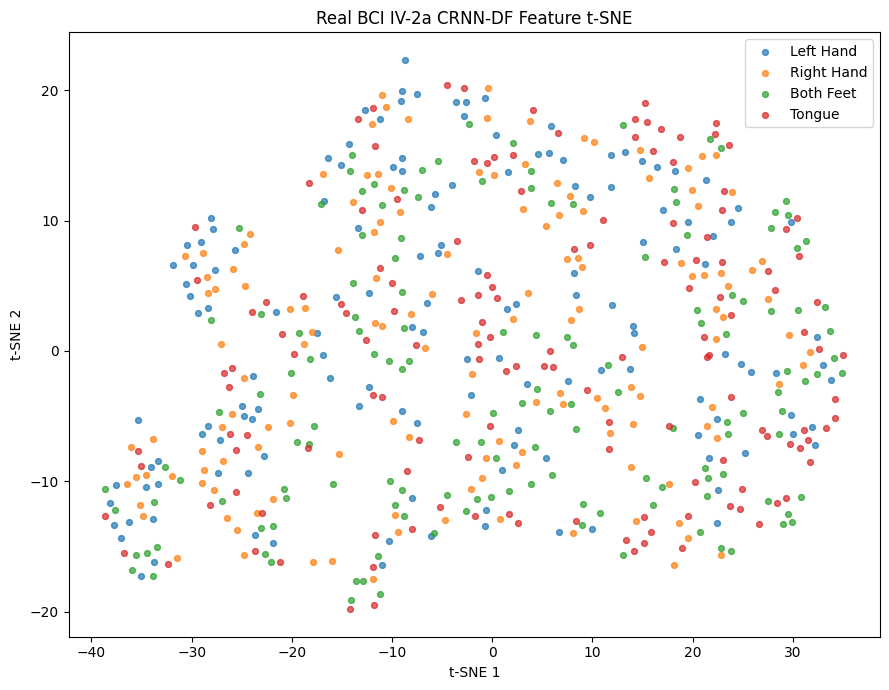


Results saved to: /Users/ashokvarmabevara/MtechProj/real_bci2a_fbgAN_crnndf_results


In [14]:

# ============================================================================
# CELL 11 - FINAL EVALUATION + t-SNE
# ============================================================================

if "RESULTS" not in globals() or not RESULTS:
    raise RuntimeError(
        "No LOSO results found. Run Cell 9 first."
    )


subjects_done = sorted(
    RESULTS.keys()
)


print("=" * 90)
print("CELL 11 - FINAL EVALUATION")
print("=" * 90)


fold_table = pd.DataFrame(
    {
        "subject": [
            f"A{subject_id}"
            for subject_id
            in subjects_done
        ],
        "accuracy_percent": [
            RESULTS[
                subject_id
            ]["accuracy"] * 100.0
            for subject_id
            in subjects_done
        ],
        "selected_fbcsp": [
            RESULTS[
                subject_id
            ]["fbcsp_selected"]
            for subject_id
            in subjects_done
        ],
    }
)

print(
    fold_table.to_string(
        index=False
    )
)


if len(subjects_done) >= 2:

    accuracies = np.asarray(
        [
            RESULTS[
                sid
            ]["accuracy"]
            for sid in subjects_done
        ]
    )

    print()
    print(
        f"Mean ± Std: "
        f"{accuracies.mean() * 100:.2f} "
        f"± "
        f"{accuracies.std(ddof=1) * 100:.2f}%"
    )

    print(
        "Published Zhang et al. benchmark: "
        "72.74 ± 10.44%"
    )

else:

    print()
    print(
        "A1 pilot only; do not report it as a 9-fold mean."
    )


# ----------------------------------------------------------------------------
# Aggregate confusion matrix.
# ----------------------------------------------------------------------------

aggregate_cm = np.zeros(
    (N_CLASSES, N_CLASSES),
    dtype=np.int64,
)

for subject_id in subjects_done:

    aggregate_cm += RESULTS[
        subject_id
    ]["confusion_matrix"]


print()
print(
    "Aggregate confusion matrix:"
)

print(
    aggregate_cm
)


# ----------------------------------------------------------------------------
# t-SNE.
# ----------------------------------------------------------------------------

all_features = np.concatenate(
    [
        RESULTS[
            subject_id
        ]["features"]
        for subject_id in subjects_done
    ],
    axis=0,
)

all_labels = np.concatenate(
    [
        RESULTS[
            subject_id
        ]["labels"]
        for subject_id in subjects_done
    ],
    axis=0,
)

all_subjects = np.concatenate(
    [
        np.full(
            len(
                RESULTS[
                    subject_id
                ]["labels"]
            ),
            subject_id,
            dtype=np.int64,
        )
        for subject_id in subjects_done
    ],
    axis=0,
)


print()
print(
    "Embeddings:",
    all_features.shape
)


if len(all_features) >= 100:

    n_points = min(
        1500,
        len(all_features),
    )

    rng = np.random.default_rng(
        SEED
    )

    indices = rng.choice(
        len(all_features),
        size=n_points,
        replace=False,
    )

    perplexity = min(
        30,
        max(
            5,
            n_points // 20,
        ),
    )

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=SEED,
    )

    embedding_2d = tsne.fit_transform(
        all_features[
            indices
        ]
    )

    plt.figure(
        figsize=(9, 7)
    )

    for class_id in range(
        N_CLASSES
    ):

        mask = (
            all_labels[
                indices
            ]
            ==
            class_id
        )

        plt.scatter(
            embedding_2d[
                mask,
                0,
            ],
            embedding_2d[
                mask,
                1,
            ],
            s=18,
            alpha=0.7,
            label=CLASS_NAMES[
                class_id
            ],
        )

    plt.title(
        "Real BCI IV-2a CRNN-DF Feature t-SNE"
    )

    plt.xlabel(
        "t-SNE 1"
    )

    plt.ylabel(
        "t-SNE 2"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ----------------------------------------------------------------------------
# Save results.
# ----------------------------------------------------------------------------

out_dir = Path(
    "real_bci2a_fbgAN_crnndf_results"
)

out_dir.mkdir(
    parents=True,
    exist_ok=True,
)

fold_table.to_csv(
    out_dir /
    "fold_results.csv",
    index=False,
)

np.save(
    out_dir /
    "aggregate_confusion.npy",
    aggregate_cm,
)

np.save(
    out_dir /
    "embeddings.npy",
    all_features,
)

np.save(
    out_dir /
    "labels.npy",
    all_labels,
)

np.save(
    out_dir /
    "subjects.npy",
    all_subjects,
)

print()
print(
    f"Results saved to: "
    f"{out_dir.resolve()}"
)
